<a href="https://colab.research.google.com/github/doomguy0991/dls_c/blob/main/C1%20-%20Neural%20Networks%20and%20Deep%20Learning/Week%204/Deep%20Neural%20Network%20Application_%20Image%20Classification/N_Deep%20Neural%20Network%20-%20Application%20v8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import os

# Check if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Setting up Colab environment...")

    # 1. Clone the repository
    repo_url = "https://github.com/doomguy0991/dls_c.git"
    # Only clone if the directory doesn't exist yet
    if not os.path.exists("/content/dls_c"):
        !git clone $repo_url /content/dls_c

    # 2. Change working directory to the notebook's location so relative paths for libraries work imports
    %cd "/content/dls_c/C1 - Neural Networks and Deep Learning/Week 4/Deep Neural Network Application_ Image Classification"

    print("Setup complete. You can now run the rest of the notebook.")
else:
    print("Running locally or out of Colab. No setup needed.")


Setting up Colab environment...
/content/dls_c/C1 - Neural Networks and Deep Learning/Week 4/Deep Neural Network Application_ Image Classification
Setup complete. You can now run the rest of the notebook.


In [45]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scipy
from PIL import Image
from scipy import ndimage

%matplotlib inline

### Load Dataset and preprocessing

(12288, 209)
(1, 209)
(12288, 50)
(1, 50)
y = 1. It's a cat picture.


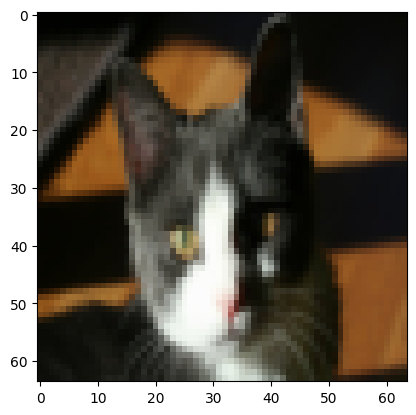

In [46]:
#---------------------- Load Data --------------------------
train_dataset = h5py.File('datasets/train_catvnoncat.h5', "r")
test_dataset = h5py.File('datasets/test_catvnoncat.h5', "r")

# get keys of dataset
# print(list(train_dataset.keys()))

# getting to know the shape of dataset by keys
# for key in train_dataset.keys():
#   data = train_dataset[key]
#   print(f"{key}: shape={data.shape}, dtype={data.dtype}")

train_set_x_orig = np.array(train_dataset["train_set_x"][:])
train_set_y_orig = np.array(train_dataset["train_set_y"][:])

test_set_x_orig = np.array(test_dataset["test_set_x"][:])
test_set_y_orig = np.array(test_dataset["test_set_y"][:])

classes = np.array(train_dataset["list_classes"][:])

#---------------------- Reshape --------------------------

X_train = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
X_test = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T

Y_test = test_set_y_orig.reshape(1, test_set_y_orig.shape[0])
Y_train = train_set_y_orig.reshape(1, train_set_y_orig.shape[0])


print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

#---------------------- Standardize --------------------------
X_train = X_train /255.0
X_test = X_test / 255.0

#---------------------- Visualize --------------------------
index = 19
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y_orig[index]) + ". It's a " + classes[train_set_y_orig[index]].decode("utf-8") +  " picture.")

### Prev defined model

In [47]:
import numpy as np


# =====================================================
# 1. ACTIVATION FUNCTIONS
# =====================================================

def relu(Z):
    """
    ReLU activation: max(0, Z)

    Input:
        Z : linear output of current layer

    Returns:
        A : activated output
        Z : stored for backward pass
    """
    A = np.maximum(0, Z)
    return A, Z


def sigmoid(Z):
    """
    Sigmoid activation: 1 / (1 + e^-Z)

    Input:
        Z : linear output

    Returns:
        A : activated output
        Z : stored for backward pass
    """
    A = 1 / (1 + np.exp(-Z))
    return A, Z


def relu_backward(dA, Z):
    """
    Backward for ReLU

    dA = gradient of cost w.r.t activation output
    Returns dZ
    """
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ


def sigmoid_backward(dA, Z):
    """
    Backward for Sigmoid

    dA = gradient of cost w.r.t activation output
    Returns dZ
    """
    s = 1 / (1 + np.exp(-Z))
    dZ = dA * s * (1 - s)
    return dZ


# =====================================================
# 2. PARAMETER INITIALIZATION
# =====================================================

def initialize_parameters(layer_dims):
    """
    layer_dims = list of neurons in each layer

    Example:
        [5, 4, 3, 1]

    Means:
        input = 5
        hidden1 = 4
        hidden2 = 3
        output = 1
    """
    np.random.seed(1)
    params = {}

    L = len(layer_dims)

    for l in range(1, L):
        params["W" + str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) / np.sqrt(layer_dims[l-1]) #*0.01
        params["b" + str(l)] = np.zeros((layer_dims[l], 1))

    return params


# =====================================================
# 3. FORWARD PROPAGATION
# =====================================================

def forward_layer(A_prev, W, b, activation):
    """
    One layer forward step

    Inputs:
        A_prev : output from previous layer
        W      : weights
        b      : bias
        activation : "relu" or "sigmoid"

    Returns:
        A      : output after activation
        cache  : values needed for backward pass
    """

    Z = np.dot(W, A_prev) + b

    if activation == "relu":
        A, act_cache = relu(Z)
    else:
        A, act_cache = sigmoid(Z)

    cache = (A_prev, W, b, act_cache)
    return A, cache


def forward_model(X, params):
    """
    Full forward pass for L-layer model

    Hidden layers use ReLU
    Last layer uses Sigmoid
    """

    caches = []
    A = X
    L = len(params) // 2

    # Hidden layers
    for l in range(1, L):
        A_prev = A
        A, cache = forward_layer(A_prev,
                                 params["W"+str(l)],
                                 params["b"+str(l)],
                                 "relu")
        caches.append(cache)

    # Output layer
    AL, cache = forward_layer(A,
                              params["W"+str(L)],
                              params["b"+str(L)],
                              "sigmoid")
    caches.append(cache)

    return AL, caches


# =====================================================
# 4. COST FUNCTION
# =====================================================

def compute_cost(AL, Y):
    """
    Binary cross-entropy cost
    """

    m = Y.shape[1]

    cost = -(1/m) * np.sum(Y*np.log(AL) + (1-Y)*np.log(1-AL))
    return np.squeeze(cost)


# =====================================================
# 5. BACKWARD PROPAGATION
# =====================================================

def backward_layer(dA, cache, activation):
    """
    One layer backward step
    """

    A_prev, W, b, Z = cache
    m = A_prev.shape[1]

    # Activation backward
    if activation == "relu":
        dZ = relu_backward(dA, Z)
    else:
        dZ = sigmoid_backward(dA, Z)

    # Linear backward
    dW = (1/m) * np.dot(dZ, A_prev.T)
    db = (1/m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)

    return dA_prev, dW, db


def backward_model(AL, Y, caches):
    """
    Full backward pass
    """

    grads = {}
    L = len(caches)

    Y = Y.reshape(AL.shape)

    # Output layer derivative
    dAL = -(np.divide(Y, AL) - np.divide(1-Y, 1-AL))

    # Last layer (sigmoid)
    dA_prev, dW, db = backward_layer(dAL, caches[L-1], "sigmoid")
    grads["dW"+str(L)] = dW
    grads["db"+str(L)] = db

    # Hidden layers
    for l in reversed(range(L-1)):
        dA_prev, dW, db = backward_layer(dA_prev, caches[l], "relu")
        grads["dW"+str(l+1)] = dW
        grads["db"+str(l+1)] = db

    return grads


# =====================================================
# 6. UPDATE PARAMETERS
# =====================================================

def update_parameters(params, grads, learning_rate):
    """
    Gradient descent update
    """

    L = len(params) // 2

    for l in range(1, L+1):
        params["W"+str(l)] -= learning_rate * grads["dW"+str(l)]
        params["b"+str(l)] -= learning_rate * grads["db"+str(l)]

    return params


# =====================================================
# 7. PREDICT
# =====================================================

def predict(X, params):
    """
    Predict 0 or 1
    """

    AL, _ = forward_model(X, params)
    predictions = (AL > 0.5).astype(int)

    return predictions

def predict_and_accuracy(X, Y, params):
    """
    Predict 0 or 1 and calculate accuracy
    """

    predictions = predict(X, params)
    correct_guess = np.dot(Y, predictions.T)
    correct_guess +=  np.dot(1 - Y, 1 - predictions.T)


    # accuracy = correct_guess / all guess *100%

    accuracy = correct_guess / float(Y.shape[1]) * 100

    return np.squeeze(accuracy)

# =====================================================
# 8. Cost vs Iteration
# =====================================================

def cost_vs_iteration(costs, learning_rate):
  plt.plot(np.squeeze(costs))
  plt.ylabel('cost')
  plt.xlabel('iterations (per hundreds)')
  plt.title("Learning rate =" + str(learning_rate))
  plt.show()


# =====================================================
# 9. TRAIN MODEL
# =====================================================

def train_model(X, Y, layer_dims, learning_rate=0.01, iterations=3000, print_cost=False):
    """
    Full training process
    """
    np.random.seed(1)
    costs = []
    params = initialize_parameters(layer_dims)

    for i in range(iterations):

        # Forward
        AL, caches = forward_model(X, params)

        # Cost
        cost = compute_cost(AL, Y)

        # Backward
        grads = backward_model(AL, Y, caches)

        # Update
        params = update_parameters(params, grads, learning_rate)

        # Print the cost every 100 training example
        if print_cost and i % 100 == 0:
            print ("Cost after iteration %i: %f" %(i, cost))
        if i % 100 == 0:
            costs.append(cost)

    return params, costs

### 2-layer neural network

In [48]:
layer_dims = [X_train.shape[0], 7, Y_train.shape[0]]
learning_rate = 0.0075
num_iteration = 2500

params, costs = train_model(X_train, Y_train, layer_dims, learning_rate, num_iteration, True)


Cost after iteration 0: 0.695046
Cost after iteration 100: 0.589260
Cost after iteration 200: 0.523261
Cost after iteration 300: 0.449769
Cost after iteration 400: 0.420900
Cost after iteration 500: 0.372464
Cost after iteration 600: 0.347421
Cost after iteration 700: 0.317192
Cost after iteration 800: 0.266438
Cost after iteration 900: 0.219914
Cost after iteration 1000: 0.143579
Cost after iteration 1100: 0.453092
Cost after iteration 1200: 0.094994
Cost after iteration 1300: 0.080141
Cost after iteration 1400: 0.069402
Cost after iteration 1500: 0.060217
Cost after iteration 1600: 0.053274
Cost after iteration 1700: 0.047629
Cost after iteration 1800: 0.042976
Cost after iteration 1900: 0.039036
Cost after iteration 2000: 0.035683
Cost after iteration 2100: 0.032915
Cost after iteration 2200: 0.030472
Cost after iteration 2300: 0.028388
Cost after iteration 2400: 0.026615


In [49]:
# Testing accuracy
accuracy = predict_and_accuracy(X_train, Y_train, params)
print("Train accuracy : " + str(accuracy))

accuracy = predict_and_accuracy(X_test, Y_test, params)
print("Test accuracy : "+ str(accuracy))

Train accuracy : 100.0
Test accuracy : 74.0


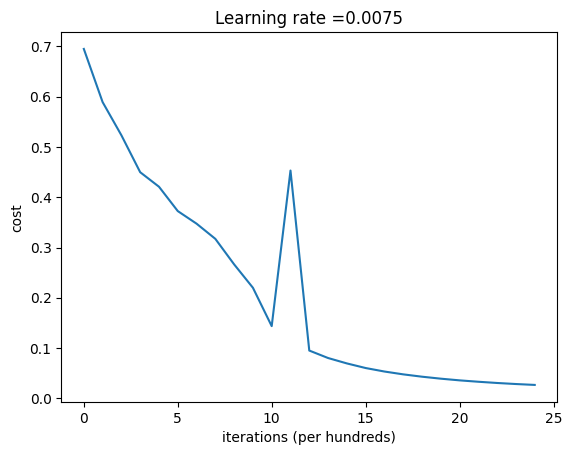

In [50]:
# Cost vs Iteration
cost_vs_iteration(costs, learning_rate)

### L-layer Neural Network

In [51]:
layer_dims = [X_train.shape[0], 20, 7, 5 , Y_train.shape[0]]
print(layer_dims)
learning_rate = 0.0075
num_iteration = 2500

params, costs = train_model(X_train, Y_train, layer_dims, learning_rate, num_iteration, True)


[12288, 20, 7, 5, 1]
Cost after iteration 0: 0.771749
Cost after iteration 100: 0.672053
Cost after iteration 200: 0.648263
Cost after iteration 300: 0.611507
Cost after iteration 400: 0.567047
Cost after iteration 500: 0.540138
Cost after iteration 600: 0.527930
Cost after iteration 700: 0.465477
Cost after iteration 800: 0.369126
Cost after iteration 900: 0.391747
Cost after iteration 1000: 0.315187
Cost after iteration 1100: 0.272700
Cost after iteration 1200: 0.237419
Cost after iteration 1300: 0.199601
Cost after iteration 1400: 0.189263
Cost after iteration 1500: 0.161189
Cost after iteration 1600: 0.148214
Cost after iteration 1700: 0.137775
Cost after iteration 1800: 0.129740
Cost after iteration 1900: 0.121225
Cost after iteration 2000: 0.113821
Cost after iteration 2100: 0.107839
Cost after iteration 2200: 0.102855
Cost after iteration 2300: 0.100897
Cost after iteration 2400: 0.092878


In [52]:
# Testing accuracy
accuracy = predict_and_accuracy(X_train, Y_train, params)
print("Train accuracy : " + str(accuracy))

accuracy = predict_and_accuracy(X_test, Y_test, params)
print("Test accuracy : "+ str(accuracy))

Train accuracy : 98.56459330143541
Test accuracy : 80.0


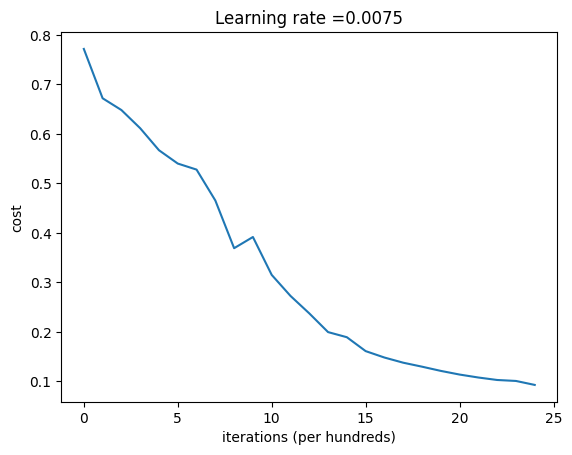

In [53]:
# Cost vs Iteration
cost_vs_iteration(costs, learning_rate)